# Quantum Fourier Transform (QFT)

QFT Analysis for Initial State: $|110\rangle$

1. Circuit Visualisation

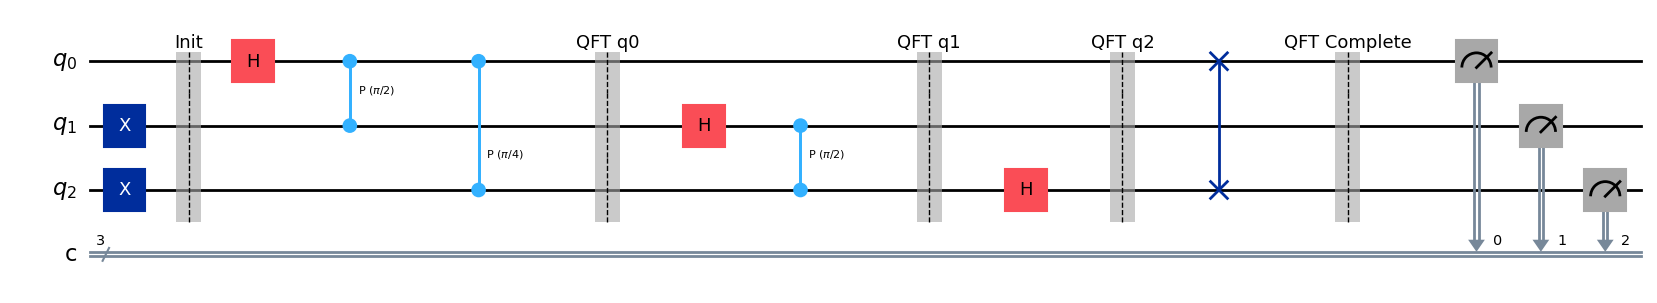

2. Unitary Evolution

The 8x8 unitary matrix describing the full QFT circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


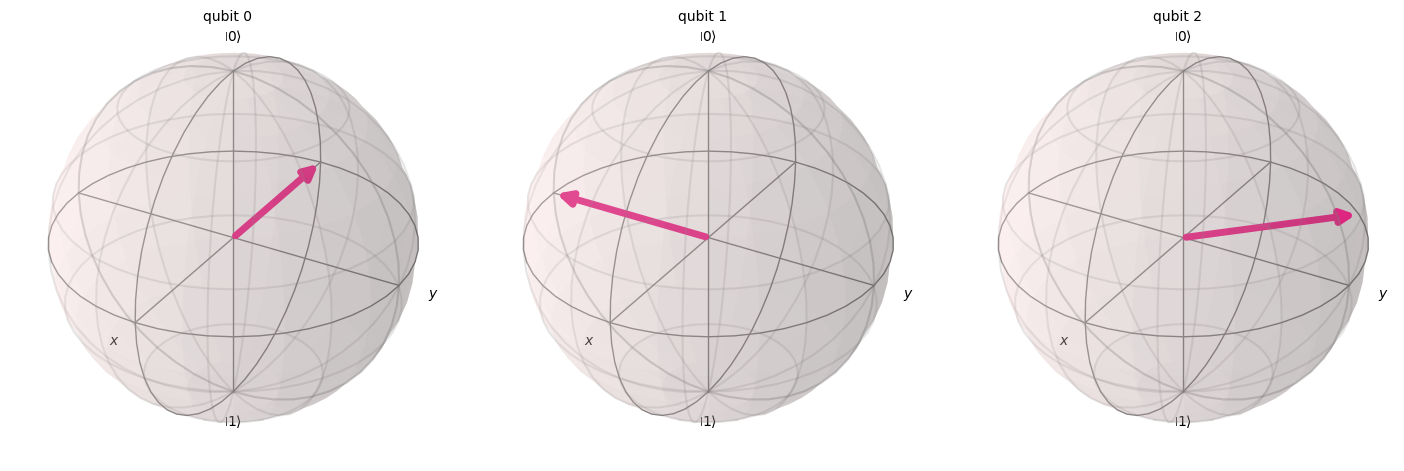


State prior to measurement (Q-Sphere):


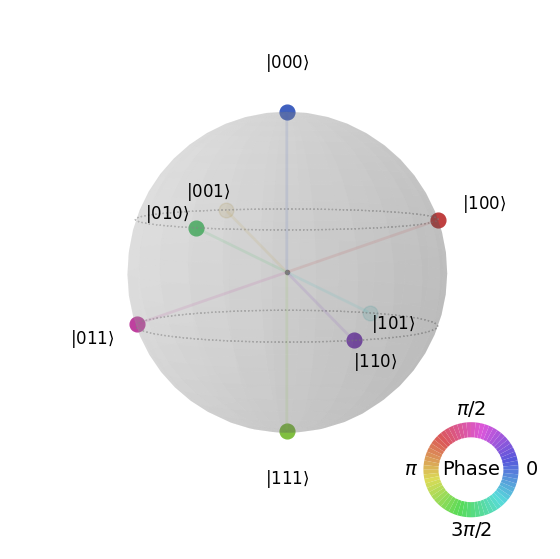

5. Measurement Analysis

Raw measurement counts: {'011': 131, '111': 114, '000': 146, '010': 119, '100': 136, '001': 144, '110': 126, '101': 108}


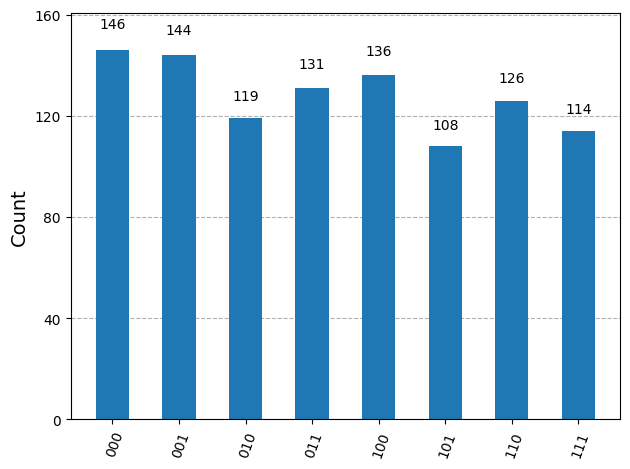

In [59]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
initial_state_str = "110"  # Target state to transform
n = len(initial_state_str)

# 1. Set up Registers & Circuit
qr = QuantumRegister(n, name="q")
cr = ClassicalRegister(n, name="c")
qc = QuantumCircuit(qr, cr)

# 2. Initialisation
# Reversing the string to match Qiskit's little-endian ordering
for i, digit in enumerate(reversed(initial_state_str)):
    if digit == '1':
        qc.x(i)
    elif digit != '0':
        raise ValueError("Invalid binary digit! Use only 0 or 1.")
qc.barrier(label="Init")

# 3. Apply QFT
for i in range(n):
    qc.h(i)
    for j in range(i + 1, n):
        # Phase is pi / 2^(distance)
        theta = np.pi / (2**(j - i))
        qc.cp(theta, j, i)
    qc.barrier(label=f"QFT q{i}")

# Swap qubits to match mathematical ordering
for i in range(n // 2):
    qc.swap(i, n - i - 1)
qc.barrier(label="QFT Complete")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 4. Measurement
qc.measure(qr, cr)

# 5. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"QFT Analysis for Initial State: $|{initial_state_str}\\rangle$"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
if n <= 3: 
    print(f"The {2**n}x{2**n} unitary matrix describing the full QFT circuit:")
    display(array_to_latex(unitary.data, prefix="U_{QFT} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {n} qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))